<a href="https://colab.research.google.com/github/Vij-Shanker/Natural-Language-Processing/blob/main/NLP_Exp_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experiment 2: Preprocessing

In this lab, we will be exploring how to preprocess tweets for sentiment analysis. We will provide a function for preprocessing tweets during this week's assignment, but it is still good to know what is going on under the hood. By the end of this lecture, you will see how to use the [NLTK](http://www.nltk.org) package to perform a preprocessing pipeline for Twitter datasets.

## Setup

You will be doing sentiment analysis on tweets in the first two weeks of this course. To help with that, we will be using the [Natural Language Toolkit (NLTK)](http://www.nltk.org/howto/twitter.html) package, an open-source Python library for natural language processing. It has modules for collecting, handling, and processing Twitter data, and you will be acquainted with them as we move along the course.

For this exercise, we will use a Twitter dataset that comes with NLTK. This dataset has been manually annotated and serves to establish baselines for models quickly. Let us import them now as well as a few other libraries we will be using.

In [122]:
import nltk                                # Python library for NLP
from nltk.corpus import twitter_samples    # sample Twitter dataset from NLTK
import matplotlib.pyplot as plt            # library for visualization
import random                              # pseudo-random number generator

## About the Twitter dataset

The sample dataset from NLTK is separated into positive and negative tweets. It contains 5000 positive tweets and 5000 negative tweets exactly. The exact match between these classes is not a coincidence. The intention is to have a balanced dataset. That does not reflect the real distributions of positive and negative classes in live Twitter streams. It is just because balanced datasets simplify the design of most computational methods that are required for sentiment analysis. However, it is better to be aware that this balance of classes is artificial.

You can download the dataset in your workspace (or in your local computer) by doing:

In [123]:
# downloads sample twitter dataset.
nltk.download('twitter_samples')

[nltk_data] Downloading package twitter_samples to /root/nltk_data...
[nltk_data]   Package twitter_samples is already up-to-date!


True

In [124]:
twitter_samples.fileids()

['negative_tweets.json', 'positive_tweets.json', 'tweets.20150430-223406.json']

In [125]:
# select the set of positive and negative tweets
positive_tweets = twitter_samples.strings('positive_tweets.json')
negative_tweets = twitter_samples.strings('negative_tweets.json')

Next, we'll print a report with the number of positive and negative tweets. It is also essential to know the data structure of the datasets

In [126]:
print('Number of positive tweets: ', len(positive_tweets))
print('Number of negative tweets: ', len(negative_tweets))

print('\nThe type of all_positive_tweets is: ', type(positive_tweets))
print('The type of a tweet entry is: ', type(negative_tweets[0]))

Number of positive tweets:  5000
Number of negative tweets:  5000

The type of all_positive_tweets is:  <class 'list'>
The type of a tweet entry is:  <class 'str'>


## Looking at raw texts

Before anything else, we can print a couple of tweets from the dataset to see how they look. Understanding the data is responsible for 80% of the success or failure in data science projects. We can use this time to observe aspects we'd like to consider when preprocessing our data.

Below, you will print one random positive and one random negative tweet. We have added a color mark at the beginning of the string to further distinguish the two. (Warning: This is taken from a public dataset of real tweets and a very small portion has explicit content.)

In [127]:
positive_tweets[2]

'@DespiteOfficial we had a listen last night :) As You Bleed is an amazing track. When are you in Scotland?!'

In [128]:
negative_tweets[3]

'“@ketchBurning: I hate Japanese call him "bani" :( :(”\n\nMe too'

We can see that the data is stored in a list and as you might expect, individual tweets are stored as strings.

**Next: To transform the list into a pandas DataFrame**

In [129]:
import pandas as pd
positive_tweets=pd.DataFrame(positive_tweets,columns=["Tweets"])
negative_tweets=pd.DataFrame(negative_tweets,columns=["Tweets"])

In [130]:
positive_tweets["Sentiments"]="positive"
positive_tweets

,Tweets,Sentiments
0,#FollowFriday @France_Inte @PKuchly57 @Milipol_Paris for being top engaged members in my community this week :),positive
1,@Lamb2ja Hey James! How odd :/ Please call our Contact Centre on 02392441234 and we will be able to assist you :) Many thanks!,positive
2,@DespiteOfficial we had a listen last night :) As You Bleed is an amazing track. When are you in Scotland?!,positive
3,@97sides CONGRATS :),positive
4,yeaaaah yippppy!!! my accnt verified rqst has succeed got a blue tick mark on my fb profile :) in 15 days,positive
...,...,...
4995,"@chriswiggin3 Chris, that's great to hear :) Due times &amp; reminders are indeed planned, both will be available in the not too distant future!",positive
4996,@RachelLiskeard Thanks for the shout-out :) It's great to have you aboard @inkfunnel,positive
4997,@side556 Hey! :) Long time no talk...,positive
4998,@staybubbly69 as Matt would say. WELCOME TO ADULTHOOD.... :) http://t.co/zHQy0iyaCP,positive


In [131]:
negative_tweets["Sentiments"]="negative"
negative_tweets

,Tweets,Sentiments
0,hopeless for tmr :(,negative
1,Everything in the kids section of IKEA is so cute. Shame I'm nearly 19 in 2 months :(,negative
2,@Hegelbon That heart sliding into the waste basket. :(,negative
3,"“@ketchBurning: I hate Japanese call him ""bani"" :( :(”\n\nMe too",negative
4,"Dang starting next week I have ""work"" :(",negative
...,...,...
4995,I wanna change my avi but uSanele :(,negative
4996,MY PUPPY BROKE HER FOOT :(,negative
4997,where's all the jaebum baby pictures :((,negative
4998,But but Mr Ahmad Maslan cooks too :( https://t.co/ArCiD31Zv6,negative


Now concatenating both the dataframes column wise and resetting the indices

In [132]:
all_tweets=pd.concat([positive_tweets,negative_tweets],ignore_index=True)
all_tweets

,Tweets,Sentiments
0,#FollowFriday @France_Inte @PKuchly57 @Milipol_Paris for being top engaged members in my community this week :),positive
1,@Lamb2ja Hey James! How odd :/ Please call our Contact Centre on 02392441234 and we will be able to assist you :) Many thanks!,positive
2,@DespiteOfficial we had a listen last night :) As You Bleed is an amazing track. When are you in Scotland?!,positive
3,@97sides CONGRATS :),positive
4,yeaaaah yippppy!!! my accnt verified rqst has succeed got a blue tick mark on my fb profile :) in 15 days,positive
...,...,...
9995,I wanna change my avi but uSanele :(,negative
9996,MY PUPPY BROKE HER FOOT :(,negative
9997,where's all the jaebum baby pictures :((,negative
9998,But but Mr Ahmad Maslan cooks too :( https://t.co/ArCiD31Zv6,negative


In [133]:
all_tweets.iloc[4]

,4
Tweets,yeaaaah yippppy!!! my accnt verified rqst has succeed got a blue tick mark on my fb profile :) in 15 days
Sentiments,positive


In [134]:
all_tweets = all_tweets.sample(frac=1, random_state=42).reset_index(drop=True)
all_tweets

,Tweets,Sentiments
0,"I love you, how but you? @Taecyeon2pm8 did you feel the same? Emm I think not :(",negative
1,@mayusushita @dildeewana_ @sonalp2591 @deepti_ahmd @armansushita8 Thanks Guys :),positive
2,"Your love, O Lord, is better than life. :) &lt;3 https://t.co/KPCeYJqKLM",positive
3,@yasminyasir96 yeah but it will be better if we use her official Account :) Like The Other @PracchiNDesai ❤️,positive
4,Ok good night I wish troye wasn't ugly and I met him today:)():)!:!; but ok today was fun I'm excited for tmrw!!,positive
...,...,...
9995,My nose and forehead are peeling :(,negative
9996,@LittleMix come to Belgium :(,negative
9997,WHY MUST THE VIDEO STOP THO :(,negative
9998,@jeremygutsche we like this amazing donut recipe! we share with #foiegras lovers! :),positive


In [135]:
all_tweets.iloc[4]

,4
Tweets,Ok good night I wish troye wasn't ugly and I met him today:)():)!:!; but ok today was fun I'm excited for tmrw!!
Sentiments,positive


Observation: All the tweets are nicely organised in a DataFrame

Next:We can make a more visually appealing report by using Matplotlib's [pyplot](https://matplotlib.org/tutorials/introductory/pyplot.html) library. Let us see how to create a [pie chart](https://matplotlib.org/3.2.1/gallery/pie_and_polar_charts/pie_features.html#sphx-glr-gallery-pie-and-polar-charts-pie-features-py) to show the same information as above. This simple snippet will serve you in future visualizations of this kind of data.

## Visualizing the data

In [136]:
y_positive=(all_tweets["Sentiments"] == "positive").sum()
y_negative=(all_tweets["Sentiments"] == "negative").sum()
print(y_positive,y_negative)

5000 5000


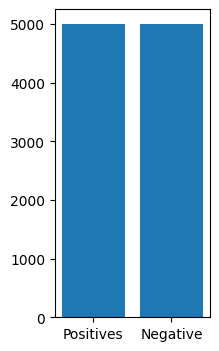

In [137]:
# Declare a figure with a custom size
fig = plt.figure(figsize=(2, 4))

# labels for the two classes
labels = ['Positives', 'Negative']

# Sizes for each slide
sizes = [y_positive, y_negative]

# Declare pie chart, where the slices will be ordered and plotted counter-clockwise:
plt.bar(labels,sizes)

# Display the chart
plt.show()

# Step 1: Preprocess raw text for Sentiment analysis

Data preprocessing is one of the critical steps in any machine learning project. It includes cleaning and formatting the data before feeding into a machine learning algorithm. For NLP, the preprocessing steps are comprised of the following tasks:

* Tokenizing the string
* Lowercasing
* Removing stop words and punctuation
* Stemming

The videos explained each of these steps and why they are important. Let's see how we can do these to a given tweet. We will choose just one and see how this is transformed by each preprocessing step.

In [138]:
# Our selected sample. Complex enough to exemplify each step
tweet1=all_tweets.iloc[1000]
tweet1["Tweets"]

'@djcunningham Thanks for the favorite! :) Make sure to keep in touch for more news of our light bulbs made from corn waste.'

### Importing libraries for text preprocessing

In [139]:
import re                                  # library for regular expression operations
import string                              # for string operations
from nltk.corpus import stopwords          # module for stop words that come with NLTK
from nltk.stem import PorterStemmer        # module for stemming
from nltk.tokenize import TweetTokenizer   # module for tokenizing strings

### Remove hyperlinks,  Twitter marks and styles

Since we have a Twitter dataset, we'd like to remove some substrings commonly used on the platform like the hashtag, retweet marks, and hyperlinks. We'll use the [re](https://docs.python.org/3/library/re.html) library to perform regular expression operations on our tweet. We'll define our search pattern and use the `sub()` method to remove matches by substituting with an empty character (i.e. `''`)

In [140]:
# remove old style retweet text "RT"
tweet2 = re.sub(r'^RT[\s]+', '', tweet1["Tweets"])

# remove hyperlinks
tweet2 = re.sub(r'https?://[^\s\n\r]+', '', tweet2)

# remove hashtags
# only removing the hash # sign from the word
tweet2 = re.sub(r'#', '', tweet2)
tweet2 = re.sub(r'@', '', tweet2)
tweet2 = re.sub(r'[:)|(:]', '', tweet2)
print(tweet1["Tweets"])
print("\n Cleaned tweet: \n",tweet2)

@djcunningham Thanks for the favorite! :) Make sure to keep in touch for more news of our light bulbs made from corn waste.

 Cleaned tweet: 
 djcunningham Thanks for the favorite!  Make sure to keep in touch for more news of our light bulbs made from corn waste.


### Tokenize the string

To tokenize means to split the strings into individual words without blanks or tabs. In this same step, we will also convert each word in the string to lower case. The [tokenize](https://www.nltk.org/api/nltk.tokenize.html#module-nltk.tokenize.casual) module from NLTK allows us to do these easily:

In [141]:
tokenizer = TweetTokenizer(preserve_case=False, strip_handles=True,reduce_len=True) # instantiate tokenizer class

# tokenize tweets
tweet_tokens = tokenizer.tokenize(tweet2)

print()
print('Tokenized string:\n')
print(tweet_tokens)


Tokenized string:

['djcunningham', 'thanks', 'for', 'the', 'favorite', '!', 'make', 'sure', 'to', 'keep', 'in', 'touch', 'for', 'more', 'news', 'of', 'our', 'light', 'bulbs', 'made', 'from', 'corn', 'waste', '.']


### Remove stop words and punctuations

The next step is to remove stop words and punctuation. Stop words are words that don't add significant meaning to the text. You'll see the list provided by NLTK when you run the cells below.

In [142]:
# download the stopwords from NLTK
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [143]:
#Import the english stop words list from NLTK
stopwords_english = stopwords.words('english')

print('Stop words\n')
print(stopwords_english)

print('\nPunctuation\n')
print(string.punctuation)

Stop words

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "s

#### Observation:
We can see that the stop words list above contains some words that could be important in some contexts.
These could be words like _i, not, between, because, won, against_. You might need to customize the stop words list for some applications. For our exercise, we will use the entire list.

For the punctuation, we saw earlier that certain groupings like ':)' and '...'  should be retained when dealing with tweets because they are used to express emotions. In other contexts, like medical analysis, these should also be removed.

#### Time to clean up our tokenized tweet!

In [144]:
# print()
# print('\033[92m')
print(tweet_tokens)
print()
# print('\033[94m')

tweets_clean = []

for word in tweet_tokens: # Go through every word in your tokens list
    if (word not in stopwords_english and  # remove stopwords
        word not in string.punctuation):  # remove punctuation
        tweets_clean.append(word)

print('removed stop words and punctuation:')
print(tweets_clean)

['djcunningham', 'thanks', 'for', 'the', 'favorite', '!', 'make', 'sure', 'to', 'keep', 'in', 'touch', 'for', 'more', 'news', 'of', 'our', 'light', 'bulbs', 'made', 'from', 'corn', 'waste', '.']

removed stop words and punctuation:
['djcunningham', 'thanks', 'favorite', 'make', 'sure', 'keep', 'touch', 'news', 'light', 'bulbs', 'made', 'corn', 'waste']


## To create function: process_tweet()

As shown above, preprocessing consists of multiple steps before arriving at the final list of words. We will create a function `process_tweet(tweet)` involving above steps

To obtain the same result as in the previous code cells, you will only need to call the function `process_tweet()`. Let's do that in the next cell.

In [145]:
def process_tweet(tweet):
    tokenizer = TweetTokenizer(preserve_case=False, strip_handles=True,reduce_len=True)

    tweet = re.sub(r'^RT[\s]+', '', tweet)             # remove old style retweet text "RT"

    tweet = re.sub(r'https?://[^\s\n\r]+', '', tweet)  # remove hyperlinks

    tweet = re.sub(r'#', '', tweet)                    # removing the hash # sign from the word
    tweet = re.sub(r'@', '', tweet)
    tweet = re.sub(r'[:)]', '', tweet)
    # tokenize tweets
    tweet_tokens = tokenizer.tokenize(tweet)
    stopwords_english = stopwords.words('english')
    tweets_clean = []

    for word in tweet_tokens: # Go through every word in your tokens list
        if (word not in stopwords_english and  # remove stopwords
            word not in string.punctuation):  # remove punctuation
            tweets_clean.append(word)
    return tweets_clean

In [146]:
processed_tweets=all_tweets['Tweets'].apply(process_tweet)   # applying process_tweet() to all positive tweets
all_tweets['Tweets_processed']=processed_tweets              # creating a new column of processed tweets 'Tweets_processed'
pd.set_option('display.max_colwidth',None)
all_tweets

,Tweets,Sentiments,Tweets_processed
0,"I love you, how but you? @Taecyeon2pm8 did you feel the same? Emm I think not :(",negative,"[love, taecyeon, 2pm8, feel, emm, think]"
1,@mayusushita @dildeewana_ @sonalp2591 @deepti_ahmd @armansushita8 Thanks Guys :),positive,"[mayusushita, dildeewana, sonalp, 2591, deepti_ahmd, armansushita, 8, thanks, guys]"
2,"Your love, O Lord, is better than life. :) &lt;3 https://t.co/KPCeYJqKLM",positive,"[love, lord, better, life, <3]"
3,@yasminyasir96 yeah but it will be better if we use her official Account :) Like The Other @PracchiNDesai ❤️,positive,"[yasminyasir, 96, yeah, better, use, official, account, like, pracchindesai, ❤, ️]"
4,Ok good night I wish troye wasn't ugly and I met him today:)():)!:!; but ok today was fun I'm excited for tmrw!!,positive,"[ok, good, night, wish, troye, ugly, met, today, ok, today, fun, excited, tmrw]"
...,...,...,...
9995,My nose and forehead are peeling :(,negative,"[nose, forehead, peeling]"
9996,@LittleMix come to Belgium :(,negative,"[littlemix, come, belgium]"
9997,WHY MUST THE VIDEO STOP THO :(,negative,"[must, video, stop, tho]"
9998,@jeremygutsche we like this amazing donut recipe! we share with #foiegras lovers! :),positive,"[jeremygutsche, like, amazing, donut, recipe, share, foiegras, lovers]"


In [147]:
processed_tweets_all=all_tweets[['Tweets_processed','Sentiments']]

In [148]:
processed_tweets_all.head()

,Tweets_processed,Sentiments
0,"[love, taecyeon, 2pm8, feel, emm, think]",negative
1,"[mayusushita, dildeewana, sonalp, 2591, deepti_ahmd, armansushita, 8, thanks, guys]",positive
2,"[love, lord, better, life, <3]",positive
3,"[yasminyasir, 96, yeah, better, use, official, account, like, pracchindesai, ❤, ️]",positive
4,"[ok, good, night, wish, troye, ugly, met, today, ok, today, fun, excited, tmrw]",positive


In [149]:
processed_tweets_all["Tweets"] = processed_tweets_all["Tweets_processed"].apply(lambda x: " ".join(x))

In [150]:
processed_tweets_all2=processed_tweets_all[['Tweets','Sentiments']]
processed_tweets_all2.head()

,Tweets,Sentiments
0,love taecyeon 2pm8 feel emm think,negative
1,mayusushita dildeewana sonalp 2591 deepti_ahmd armansushita 8 thanks guys,positive
2,love lord better life <3,positive
3,yasminyasir 96 yeah better use official account like pracchindesai ❤ ️,positive
4,ok good night wish troye ugly met today ok today fun excited tmrw,positive


# Step 2: Convert text into numerical features
### Bag of Words (Recommended for beginners)

In [151]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()

X = vectorizer.fit_transform(processed_tweets_all2["Tweets"])

# Step 3: Encode the labels

In [152]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y = encoder.fit_transform(processed_tweets_all2["Sentiments"])

# Step 4: Split the dataset

In [153]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Step 5: Train a classifier

### Naïve Bayes

In [154]:
from sklearn.naive_bayes import MultinomialNB

model_NB = MultinomialNB()

model_NB.fit(X_train, y_train)

MultinomialNB()

### Logistic Regression

In [155]:
from sklearn.linear_model import LogisticRegression

model_LR = LogisticRegression(max_iter=1000)

model_LR.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

### Support Vector Machine

In [156]:
from sklearn.svm import LinearSVC

model_SVM = LinearSVC()

model_SVM.fit(X_train, y_train)

LinearSVC()

### Decision Tress

In [157]:
from sklearn.tree import DecisionTreeClassifier

model_DT = DecisionTreeClassifier()

model_DT.fit(X_train, y_train)

DecisionTreeClassifier()

### Random Forset

In [158]:
from sklearn.ensemble import RandomForestClassifier

model_RF = RandomForestClassifier()

model_RF.fit(X_train, y_train)

RandomForestClassifier()

# Step 6: Prediction

In [159]:
y_pred = model_RF.predict(X_test)

# Step 7: Evaluation

In [160]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

Accuracy: 0.727
              precision    recall  f1-score   support

           0       0.69      0.80      0.74       987
           1       0.77      0.65      0.71      1013

    accuracy                           0.73      2000
   macro avg       0.73      0.73      0.73      2000
weighted avg       0.73      0.73      0.73      2000

[[793 194]
 [352 661]]


# Step 8: Predict a new tweet

In [176]:
new_tweet = "I really enjoy the movie"

# preprocess as done during training
new_tweet = new_tweet.lower()

new_vector = vectorizer.transform([new_tweet])

prediction = model_RF.predict(new_vector)

print(encoder.inverse_transform(prediction))

['positive']
